In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score, mean_squared_error

import sys
import os

notebook_dir = os.getcwd() 
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))  # ../src
sys.path.append(src_path)
from regression import linear_func, log_func, power_func, quadratic_func, fit_models
from regression import plot_leadtime_regression, plot_validation_from_fitted


sns.set(style="whitegrid") 
df_clean = pd.read_parquet('../data/hotels_clean.parquet' , engine='fastparquet') 
print(f"Cleaned dataset shape: {df_clean.shape}")
display(df_clean.head(3))

Cleaned dataset shape: (78528, 19)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,total_guests,total_nights
0,Resort Hotel,0,7,2015,July,27,1,0,1,1,0,0,0,0,0,A,C,1,1
1,Resort Hotel,0,13,2015,July,27,1,0,1,1,0,0,0,0,0,A,A,1,1
2,Resort Hotel,0,14,2015,July,27,1,0,2,2,0,0,0,0,0,A,A,2,2


In [2]:
# --- Filter dataset to exclude unusual bookings ---
#   - guests: adults ≤ 4 & children ≤ 3
#   - stay nights: total_nights ≤ 11 (98% percentile covers most of the data)

df_filtered_0 = df_clean[
    (df_clean['adults'] <= 4) & 
    (df_clean['children'] <= 3) & 
    (df_clean['total_nights'] <= 11)
].copy()


In [3]:
# --- Data Preparation: Train & Validation ---
df_filtered = df_filtered_0.copy()

from sklearn.model_selection import train_test_split
df_train, df_val = train_test_split(df_filtered, test_size=0.3, random_state=42, shuffle=True)

df_train_clean = df_train.dropna(subset=['lead_time','is_canceled'])
df_train_clean = df_train_clean[(df_train_clean['lead_time'] > 0) & (df_train_clean['lead_time'] <= 316)]

df_val_clean = df_val.dropna(subset=['lead_time','is_canceled'])
df_val_clean = df_val_clean[(df_val_clean['lead_time'] > 0) & (df_val_clean['lead_time'] <= 316)]

train_stats = df_train_clean.groupby('lead_time').agg(is_canceled=('is_canceled', 'mean')).reset_index()
val_stats   = df_val_clean.groupby('lead_time').agg(is_canceled=('is_canceled', 'mean')).reset_index()

mask_train = (train_stats['lead_time'] > 0) & (train_stats['lead_time'] <= 199)
mask_val   = (val_stats['lead_time'] > 0) & (val_stats['lead_time'] <= 199)
train_stats = train_stats[mask_train]
val_stats   = val_stats[mask_val]

common_leads = np.intersect1d(train_stats['lead_time'], val_stats['lead_time'])
train_stats = train_stats[train_stats['lead_time'].isin(common_leads)]
val_stats   = val_stats[val_stats['lead_time'].isin(common_leads)]

x_train = train_stats['lead_time'].values
y_train = train_stats['is_canceled'].values

x_val   = val_stats['lead_time'].values
y_val   = val_stats['is_canceled'].values

Figure saved to ../figures/leadtime_regression_fit.png


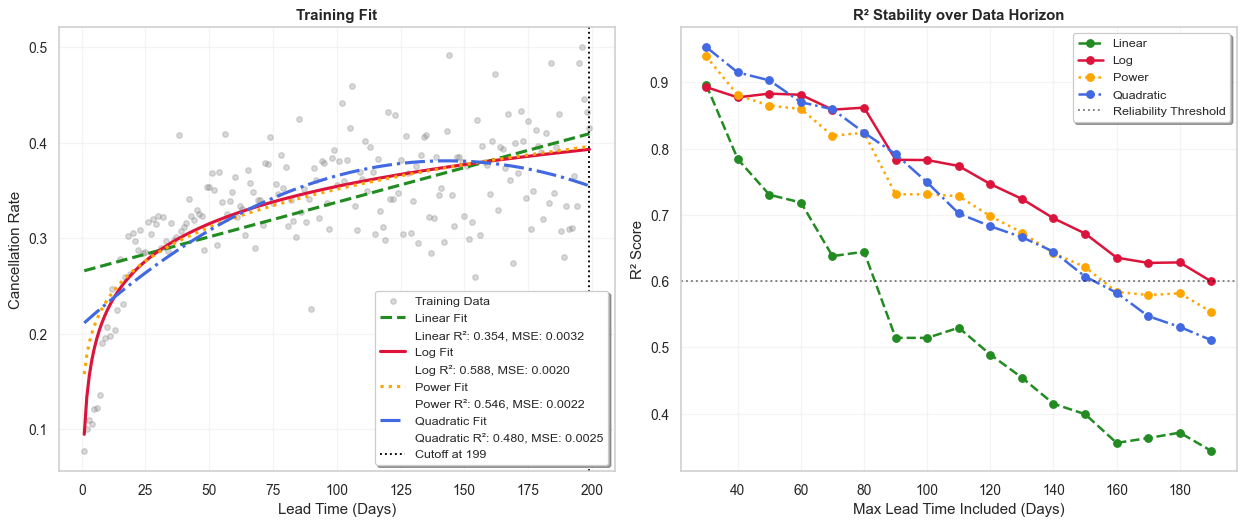

In [4]:
colors = {
    'Linear': ('forestgreen', '--'),
    'Log': ('crimson', '-'),
    'Power': ('orange', ':'),
    'Quadratic': ('royalblue', '-.')
}

fitted_models = fit_models(x_train, y_train)

plot_leadtime_regression(x_train, y_train, fitted_models=fitted_models, colors=colors, days_range=range(30, 199, 10), cutoff_day=199, save_path="../figures/leadtime_regression_fit.png")

In [5]:
print(plot_leadtime_regression.__code__.co_filename)

/Users/lanlan/Hotel-Booking-Behavior-Analysis-with-Seasonal-and-Regression-Modeling/src/regression.py


Figure saved to ../figures/leadtime_validation_fit.png
Linear {'r2_trust': 0.2955620160908141, 'mse_trust': 0.006102865627932564, 'r2_all': 0.3690329998262366, 'mse_all': 0.01099392534894739}
Log {'r2_trust': 0.4230094768713216, 'mse_trust': 0.004998730493923502, 'r2_all': 0.2789482388074115, 'mse_all': 0.012563555991193315}
Power {'r2_trust': 0.39984917805258724, 'mse_trust': 0.005199378662849786, 'r2_all': 0.2956928649581291, 'mse_all': 0.012271798783849153}
Quadratic {'r2_trust': 0.3407185318940602, 'mse_trust': 0.005711654258773414, 'r2_all': -0.9454391617834739, 'mse_all': 0.03389719733310333}


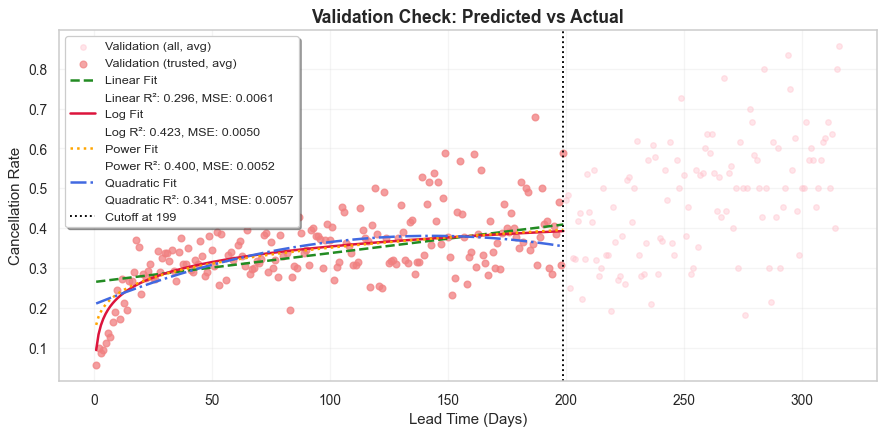

In [6]:
results_val = plot_validation_from_fitted(fitted_models, df_val_clean, cutoff_day=199, save_path="../figures/leadtime_validation_fit.png")

for name, metrics in results_val.items():
    print(name, metrics)